In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization,
    RandomRotation, RandomTranslation, RandomZoom)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [2]:
# wczytanie danych

# dane
(images, labels), _ = tf.keras.datasets.fashion_mnist.load_data()

# nazwy klas (do wyświetlania)
class_names = [
    'T-shirt/top','Trouser','Pullover','Dress','Coat',
    'Sandal','Shirt','Sneaker','Bag','Ankle boot']

In [3]:
# podzial danych
X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels,
    test_size=0.1,
    random_state=10,
    stratify=labels)

In [4]:
# przygotownie danych

# normalizacja
X_train = X_train / 255.0
X_test = X_test / 255.0

# dodanie kanalu (CNN wymaga 4D: wysokosc, szerokosc, kanal)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [6]:
# prosty model

f_mnist_model = Sequential([
    Conv2D(32, 3, padding='same', activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(),

    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D(),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(10, activation='softmax')])


C:\Users\atrel\anaconda3\envs\tf\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# kompilacja modelu
f_mnist_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

f_mnist_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# trening modelu

history = f_mnist_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.1)

Epoch 1/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.7913 - loss: 0.5787 - val_accuracy: 0.8774 - val_loss: 0.3440
Epoch 2/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.8678 - loss: 0.3724 - val_accuracy: 0.8867 - val_loss: 0.3079
Epoch 3/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.8856 - loss: 0.3193 - val_accuracy: 0.9011 - val_loss: 0.2673
Epoch 4/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.8967 - loss: 0.2877 - val_accuracy: 0.9148 - val_loss: 0.2429
Epoch 5/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.9036 - loss: 0.2628 - val_accuracy: 0.9185 - val_loss: 0.2315
Epoch 6/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.9102 - loss: 0.2460 - val_accuracy: 0.9150 - val_loss: 0.2313
Epoch 7/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.9161 - loss: 0.2280 - val_accuracy: 0.9215 - val_loss: 0.2180
Epoch 8/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.9212 - loss: 0.2131 - 

In [9]:
# ocena prostego modelu

loss_basic, accuracy_basic = f_mnist_model.evaluate(X_test, y_test)

print("Loss modelu prostego:", loss_basic)
print("Accuracy modelu prostego:", accuracy_basic)

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9228 - loss: 0.2476
Loss modelu prostego: 0.24755534529685974
Accuracy modelu prostego: 0.9228333234786987


In [10]:
# zapisani modelu

f_mnist_model.save("fashion_mnist_model_basic.keras")

In [11]:
loaded_model = load_model("fashion_mnist_model_basic.keras")

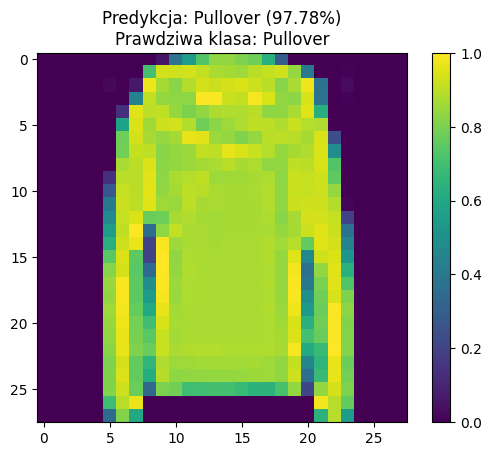

{'predykcja': 'Pullover',
 'prawdziwa_klasa': 'Pullover',
 'pewnosc': 0.9777836203575134,
 'prawdopodobienstwa': array([3.2772232e-07, 3.0858166e-10, 9.7778362e-01, 1.4960765e-10,
        2.2146329e-02, 2.8007939e-12, 6.9658126e-05, 1.9845263e-16,
        2.6761601e-10, 9.6405739e-13], dtype=float32)}

In [12]:
def przewidz_klase(index, model=loaded_model):
    """
    Funkcja przyjmuje indeks obrazu ze zbioru testowego,
    pokazuje obraz i zwraca klas przewidziana przez model.
    """

    obraz = X_test[index]
    prawdziwa_klasa = y_test[index]

    predykcja = model.predict(np.expand_dims(obraz, axis=0), verbose=0)

    przewidziana_klasa = np.argmax(predykcja)
    pewnosc = np.max(predykcja)

    plt.imshow(obraz.reshape(28, 28), cmap="viridis")
    plt.colorbar()
    plt.title(
        f"Predykcja: {class_names[przewidziana_klasa]} ({pewnosc:.2%})\n"
        f"Prawdziwa klasa: {class_names[prawdziwa_klasa]}")
    plt.show()

    return {
        "predykcja": class_names[przewidziana_klasa],
        "prawdziwa_klasa": class_names[prawdziwa_klasa],
        "pewnosc": float(pewnosc),
        "prawdopodobienstwa": predykcja[0]}


# przyklad
przewidz_klase(0)

In [13]:
# MODEL Z AUGUMENTACJA Z UZYCIEM ALBUMENTATIONS - sztucznie zwiekszamy dane

import albumentations as A

# definiujemy transformacje augmentacji
augmentacja = A.Compose([
    A.ShiftScaleRotate(
        shift_limit=0.03,
        scale_limit=0.03,
        rotate_limit=5,
        p=0.5)])


# fcja tworzy powiekszony zbior danych:
# bierze oryginalne obrazy
# dla każdego tworzy dodatkową, lekko zmienioną wersję
def zrob_augumentacje(X, y):
    X_aug = []
    y_aug = []

    for obraz, etykieta in zip(X, y):
        # dodajemy oryginalny obraz
        X_aug.append(obraz)
        y_aug.append(etykieta)

        # Albumentations na obrazie 2D
        obraz_2d = obraz.reshape(28, 28)

        # tworzymy obraz
        obraz_aug = augmentacja(image=obraz_2d)["image"]

        #dodajemy kanal z powrotem
        obraz_aug = obraz_aug.reshape(28, 28, 1)

        X_aug.append(obraz_aug)
        y_aug.append(etykieta)

    return np.array(X_aug), np.array(y_aug)


# tworzym rozszerzony zbior treningowy
X_train_aug, y_train_aug = zrob_augumentacje(X_train, y_train)

print("Rozmiar przed augmentacją:", X_train.shape)
print("Rozmiar po augmentacji:", X_train_aug.shape)

C:\Users\atrel\anaconda3\envs\tf\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Rozmiar przed augmentacją: (54000, 28, 28, 1)
Rozmiar po augmentacji: (108000, 28, 28, 1)


In [15]:
# moedl CNN trenowany na danych z Albumentations

f_mnist_model_aug = Sequential([
    Conv2D(32, 3, padding='same', activation='relu', input_shape=(28, 28, 1)),
    BatchNormalization(),
    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Dropout(0.25),

    Conv2D(64, 3, padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Dropout(0.30),

    Conv2D(128, 3, padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Dropout(0.35),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.4),

    Dense(10, activation='softmax')])

In [16]:
# kompilacja nowego modelu

f_mnist_model_aug.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

f_mnist_model_aug.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 585,066 (2.23 MB)

 Trainable params: 584,618 (2.23 MB)

 Non-trainable params: 448 (1.75 KB)

In [17]:
# terning nowego modelu
history_aug = f_mnist_model_aug.fit(
    X_train_aug,
    y_train_aug,
    epochs=30,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/30
760/760 ━━━━━━━━━━━━━━━━━━━━ 164s 211ms/step - accuracy: 0.7985 - loss: 0.5616 - val_accuracy: 0.8661 - val_loss: 0.3571
Epoch 2/30
760/760 ━━━━━━━━━━━━━━━━━━━━ 153s 202ms/step - accuracy: 0.8798 - loss: 0.3313 - val_accuracy: 0.9102 - val_loss: 0.2451
Epoch 3/30
760/760 ━━━━━━━━━━━━━━━━━━━━ 152s 201ms/step - accuracy: 0.8978 - loss: 0.2812 - val_accuracy: 0.9040 - val_loss: 0.2574
Epoch 4/30
760/760 ━━━━━━━━━━━━━━━━━━━━ 152s 199ms/step - accuracy: 0.9070 - loss: 0.2519 - val_accuracy: 0.9164 - val_loss: 0.2227
Epoch 5/30
760/760 ━━━━━━━━━━━━━━━━━━━━ 149s 197ms/step - accuracy: 0.9150 - loss: 0.2345 - val_accuracy: 0.9284 - val_loss: 0.2010
Epoch 6/30
760/760 ━━━━━━━━━━━━━━━━━━━━ 153s 202ms/step - accuracy: 0.9183 - loss: 0.2191 - val_accuracy: 0.9252 - val_loss: 0.2112
Epoch 7/30
760/760 ━━━━━━━━━━━━━━━━━━━━ 153s 201ms/step - accuracy: 0.9222 - loss: 0.2096 - val_accuracy: 0.9322 - val_loss: 0.2010
Epoch 8/30
760/760 ━━━━━━━━━━━━━━━━━━━━ 151s 199ms/step - accuracy: 0.9270 -

In [18]:
# ocena nowego modelu

loss_aug, accuracy_aug = f_mnist_model_aug.evaluate(X_test, y_test)

print("Loss modelu ulepszonego:", loss_aug)
print("Accuracy modelu ulepszonego:", accuracy_aug)

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9348 - loss: 0.2075
Loss modelu ulepszonego: 0.2074955701828003
Accuracy modelu ulepszonego: 0.9348333477973938


In [19]:
f_mnist_model_aug.save("fashion_mnist_model_aug_albumentations.keras")

In [21]:
# porownanie modeli
import pandas as pd

porownanie = pd.DataFrame({
    "Model": [
        "Prosty CNN",
        "CNN + Albumentations"],
    "Loss": [
        loss_basic,
        loss_aug],
    "Accuracy": [
        accuracy_basic,
        accuracy_aug]})

porownanie

,Model,Loss,Accuracy
0,Prosty CNN,0.247555,0.922833
1,CNN + Albumentations,0.207496,0.934833
